# Building Self-Attention from Scratch


### What you'll build
Using only `numpy` and `matplotlib` (no deep learning framework, no API key, no GPU needed):

1. **Scaled dot-product attention**, implemented and run on hand-crafted embeddings
2. A visualization of an actual attention-weight matrix (a real heatmap, not just a description)
3. **Multi-head attention**, built by running several attention heads in parallel and concatenating
4. **Sinusoidal positional encoding**, implemented and plotted
5. A tiny, complete **single encoder block** forward pass (self-attention → add & norm → feed-forward → add & norm)



## 1. Scaled Dot-Product Attention, From Scratch

The core formula from the lecture:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

| Symbol | Meaning |
|--------|---------|
| $Q$ | **Query matrix** — represents what each token is looking for |
| $K$ | **Key matrix** — represents the information available for matching |
| $V$ | **Value matrix** — contains the actual information to be aggregated |
| $K^T$ | **Transpose of the Key matrix** — allows us to compute Query-Key similarities |
| $QK^T$ | **Dot-product similarity scores** between every Query and every Key |
| $d_k$ | **Dimension of each Key/Query vector** |
| $\sqrt{d_k}$ | **Scaling factor** used to keep dot-product values from becoming too large |
| $\frac{QK^T}{\sqrt{d_k}}$ | **Scaled attention scores** |
| $\text{softmax}(\cdot)$ | Converts the scores into **attention weights/probabilities** that sum to 1 |
| $\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)$ | **Attention weight matrix** — indicates how much each Query attends to each Key |
| $\left(\cdots\right)V$ | Computes a **weighted combination of the Value vectors** |
| $\text{Attention}(Q,K,V)$ | Final **attention output** |
Let's implement this directly.


In [1]:
import numpy as np
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)  # subtract max for numerical stability
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)   # similarity between every query and every key
    weights = softmax(scores, axis=-1)  # normalize into a probability distribution per row
    output = weights @ V              # weighted mixture of values
    return output, weights

# Quick shape/sanity check with random vectors
Q_test = np.random.randn(4, 8)
K_test = np.random.randn(4, 8)
V_test = np.random.randn(4, 8)
out, w = scaled_dot_product_attention(Q_test, K_test, V_test)
print("Output shape:", out.shape)          # (seq_len, d_v)
print("Weights shape:", w.shape)           # (seq_len, seq_len)
print("Each row of weights sums to 1:", np.allclose(w.sum(axis=1), 1.0))


Output shape: (4, 8)
Weights shape: (4, 4)
Each row of weights sums to 1: True


### Exercise- 1
- create a small array and pass it to the softmax function and print the result.

**Answer.** Softmax turns any vector of real numbers into a probability
distribution: everything positive, summing to 1. It is monotonic (the biggest input stays the
biggest output) but it *exaggerates* differences, because it exponentiates before normalising.
Two details worth noticing below: a row of equal scores comes out perfectly uniform, and the
`x - np.max(x)` line that looks redundant is the only thing standing between you and `nan`.

In [2]:
# Exercise 1 - feed a small array to softmax and look at what comes back.

a = np.array([2.0, 1.0, 0.1])
p = softmax(a)
print("input :", a)
print("softmax:", np.round(p, 4))
print("sums to:", p.sum())

# Softmax is monotonic: the largest input stays the largest output, but the
# gaps get stretched. 2.0 is 2x the size of 1.0, yet it gets ~2.7x the weight.
print("\nratio of top two weights:", round(p[0] / p[1], 3),
      " vs exp(2.0-1.0) =", round(np.exp(1.0), 3))

# axis=-1 means "normalise along the last axis", i.e. each ROW separately.
b = np.array([[1.0, 2.0, 3.0],
              [1.0, 1.0, 1.0]])
print("\n2-D input, row-wise softmax:")
print(np.round(softmax(b, axis=-1), 4))
print("row sums:", softmax(b, axis=-1).sum(axis=-1))
# Row 2 is uniform: equal scores -> equal attention. This is what an
# attention row looks like when a token has no reason to prefer anything.

# Why the function subtracts the max first (the line that looks pointless):
big = np.array([1000.0, 1001.0, 1002.0])
print("\nstable   :", np.round(softmax(big), 4))
with np.errstate(over="ignore", invalid="ignore"):
    naive = np.exp(big) / np.sum(np.exp(big))
print("naive    :", naive)
print("-> exp(1000) overflows to inf, and inf/inf is nan.")
# Subtracting the max shifts the inputs so the largest exponent is exp(0)=1.
# The result is mathematically identical because the shift cancels:
#   e^(x_i - m) / sum_j e^(x_j - m) = (e^-m . e^x_i) / (e^-m . sum_j e^x_j)
print("shifted inputs:", big - big.max(), "-> exp() of these is safe")


input : [2.  1.  0.1]
softmax: [0.659  0.2424 0.0986]
sums to: 1.0

ratio of top two weights: 2.718  vs exp(2.0-1.0) = 2.718

2-D input, row-wise softmax:
[[0.09   0.2447 0.6652]
 [0.3333 0.3333 0.3333]]
row sums: [1. 1.]

stable   : [0.09   0.2447 0.6652]
naive    : [nan nan nan]
-> exp(1000) overflows to inf, and inf/inf is nan.
shifted inputs: [-2. -1.  0.] -> exp() of these is safe


## Exercise- 2
- Make 3 arrays Q, K, V and pass it to scaled_dot_product_attention and observe the result.

**Answer.** Q, K and V play three different roles, and the shapes tell you
which is which. `Q @ K.T` compares every query against every key, so it is always
`(seq_len, seq_len)`. The weights that come out of the softmax are then applied to the *rows*
of V. Below, the vectors are hand-picked so you can predict each row before running it.

In [3]:
# Exercise 2 - build Q, K, V by hand and watch attention move information around.
#
# 3 "tokens", 4 dimensions. The vectors are deliberately readable rather than
# random, so you can predict the answer before running it.

Q_ex = np.array([[1.0, 0.0, 0.0, 0.0],     # token 0 asks for "feature 0"
                 [0.0, 1.0, 0.0, 0.0],     # token 1 asks for "feature 1"
                 [0.0, 0.0, 1.0, 0.0]])    # token 2 asks for "feature 2"

K_ex = np.array([[1.0, 0.0, 0.0, 0.0],     # token 0 advertises feature 0
                 [0.0, 1.0, 0.0, 0.0],     # token 1 advertises feature 1
                 [1.0, 0.0, 0.0, 0.0]])    # token 2 ALSO advertises feature 0

V_ex = np.array([[10.0, 0.0, 0.0, 0.0],    # the payload each token hands over
                 [0.0, 20.0, 0.0, 0.0],
                 [0.0, 0.0, 30.0, 0.0]])

out_ex, w_ex = scaled_dot_product_attention(Q_ex, K_ex, V_ex)

print("raw scores Q @ K.T:")
print(Q_ex @ K_ex.T)
print("\nafter dividing by sqrt(d_k) =", np.sqrt(4))
print(np.round(Q_ex @ K_ex.T / np.sqrt(4), 3))
print("\nattention weights (each row sums to 1):")
print(np.round(w_ex, 4))
print("\noutput:")
print(np.round(out_ex, 3))

# Reading it:
# Row 0 - query 0 matches keys 0 AND 2 (both advertise feature 0), so its
#         attention splits between them and its output mixes V[0] and V[2].
# Row 1 - query 1 matches only key 1, so it is the peakiest row.
# Row 2 - query 2 matches nothing, so all three scores are 0 and the softmax
#         of equal scores is exactly uniform: it averages all three values.
print("\nrow 2 weights are uniform:", np.allclose(w_ex[2], 1/3))
print("row 2 output equals the plain mean of V:", np.allclose(out_ex[2], V_ex.mean(axis=0)))

# The output really is just a weighted sum of the value ROWS - nothing else.
manual = w_ex[0, 0] * V_ex[0] + w_ex[0, 1] * V_ex[1] + w_ex[0, 2] * V_ex[2]
print("\nrow 0 recomputed by hand:", np.round(manual, 3))
print("matches the function's output:", np.allclose(manual, out_ex[0]))


raw scores Q @ K.T:
[[1. 0. 1.]
 [0. 1. 0.]
 [0. 0. 0.]]

after dividing by sqrt(d_k) = 2.0
[[0.5 0.  0.5]
 [0.  0.5 0. ]
 [0.  0.  0. ]]

attention weights (each row sums to 1):
[[0.3837 0.2327 0.3837]
 [0.2741 0.4519 0.2741]
 [0.3333 0.3333 0.3333]]

output:
[[ 3.837  4.654 11.51   0.   ]
 [ 2.741  9.037  8.222  0.   ]
 [ 3.333  6.667 10.     0.   ]]

row 2 weights are uniform: True
row 2 output equals the plain mean of V: True

row 0 recomputed by hand: [ 3.837  4.654 11.51   0.   ]
matches the function's output: True


## 2. A Meaningful Worked Example: "It" and "Animal"

The lecture's classic example: *"The animal didn't cross the street because it was tired."* We want to see attention correctly link **"it" → "animal"** rather than "it" → "street".

With truly **random, untrained** weights this link is not guaranteed to appear — the model hasn't learned anything yet. So here we hand-craft small feature embeddings (entity? animate? place? function word?) to honestly demonstrate what the *mechanism* does with meaningful input, which is what a trained model's embeddings would eventually encode on their own.


In [4]:
tokens_list = ["The", "animal", "didn't", "cross", "the", "street", "because", "it", "was", "tired"]

# Hand-crafted feature embeddings -- NOT random, NOT learned.
# dims: [is_entity, is_animate, is_place, is_function_word, is_verb, is_adjective, pad, pad]
feats = {
    "The":     [0, 0, 0, 1, 0, 0, 0, 0],
    "animal":  [1, 1, 0, 0, 0, 0, 0, 0],
    "didn't":  [0, 0, 0, 1, 0, 0, 0, 0],
    "cross":   [0, 0, 0, 0, 1, 0, 0, 0],
    "the":     [0, 0, 0, 1, 0, 0, 0, 0],
    "street":  [1, 0, 1, 0, 0, 0, 0, 0],
    "because": [0, 0, 0, 1, 0, 0, 0, 0],
    "it":      [1, 1, 0, 0, 0, 0, 0, 0],   # shares [entity, animate] with "animal"
    "was":     [0, 0, 0, 1, 0, 0, 0, 0],
    "tired":   [0, 0, 0, 0, 0, 1, 0, 0],
}
X = np.array([feats[t] for t in tokens_list], dtype=float)

# Using identity-like projections here (Q = K = V = X) keeps the demo transparent --
# in a real model, W_q/W_k/W_v are learned matrices that would produce similar
# alignments automatically once trained on enough language data.
Q, K, V = X, X, X
output, attn_weights = scaled_dot_product_attention(Q, K, V)

it_idx = tokens_list.index("it")
order = np.argsort(attn_weights[it_idx])[::-1]
print("Token 'it' attends to (ranked by weight):")
for i in order[:4]:
    print(f"  {tokens_list[i]:10s}  weight={attn_weights[it_idx][i]:.3f}")


Token 'it' attends to (ranked by weight):
  animal      weight=0.163
  it          weight=0.163
  street      weight=0.114
  tired       weight=0.080


**"it" attends most strongly to "animal"** (tied with attending to itself) — clearly more than to "street" — because our hand-crafted features gave "it" and "animal" overlapping `[entity, animate]` values. This is exactly the coreference-resolution intuition from the lecture, made concrete rather than just asserted.


## Exercise
- make a token list by your own, chosse any sentence.
- create encoding for every token.
- do scaled_dot_product_attention and calculate attenstions.


**Answer.** Same code, a different sentence, and the antecedent flips.
Here "it" refers to the *ball*, not the animate noun — and attention follows, because the
features changed. Note the skeleton cell in the original notebook has a bug: it says
`Q, K, V = X, X, X`, which silently reuses the previous sentence.

In [5]:
# Exercise - your own sentence, your own features, your own attention.
#
# Sentence: "The dog chased the ball because it was rolling."
# This is the mirror image of the lecture's example. Here "it" refers to the
# INANIMATE thing, so if the mechanism is real (and not us having rigged the
# original), attention should now prefer "ball" over "dog".

tokens_list_demo = ["The", "dog", "chased", "the", "ball",
                    "because", "it", "was", "rolling"]

# dims: [is_entity, is_animate, is_object, is_function_word, is_verb, is_adjective, pad, pad]
feats_demo = {
    "The":     [0, 0, 0, 1, 0, 0, 0, 0],
    "dog":     [1, 1, 0, 0, 0, 0, 0, 0],   # entity + animate
    "chased":  [0, 0, 0, 0, 1, 0, 0, 0],
    "the":     [0, 0, 0, 1, 0, 0, 0, 0],
    "ball":    [1, 0, 1, 0, 0, 0, 0, 0],   # entity + object
    "because": [0, 0, 0, 1, 0, 0, 0, 0],
    "it":      [1, 0, 1, 0, 0, 0, 0, 0],   # entity + object  -> matches "ball"
    "was":     [0, 0, 0, 1, 0, 0, 0, 0],
    "rolling": [0, 0, 0, 0, 1, 0, 0, 0],
}
X_demo = np.array([feats_demo[t] for t in tokens_list_demo], dtype=float)

# NOTE: the skeleton in the notebook says `Q, K, V = X, X, X`, which quietly
# reuses the PREVIOUS sentence's matrix and computes the wrong thing entirely.
# It has to be X_demo.
Q_demo, K_demo, V_demo = X_demo, X_demo, X_demo
output_demo, attn_weights_demo = scaled_dot_product_attention(Q_demo, K_demo, V_demo)

it_demo = tokens_list_demo.index("it")
order = np.argsort(attn_weights_demo[it_demo])[::-1]
print("Token 'it' attends to (ranked):")
for i in order[:5]:
    print(f"  {tokens_list_demo[i]:10s} weight={attn_weights_demo[it_demo][i]:.3f}")

w_ball = attn_weights_demo[it_demo][tokens_list_demo.index("ball")]
w_dog = attn_weights_demo[it_demo][tokens_list_demo.index("dog")]
print(f"\n'ball' {w_ball:.3f}  vs  'dog' {w_dog:.3f}   ->  ratio {w_ball/w_dog:.2f}x")
print("The raw scores behind that: it.ball =", X_demo[it_demo] @ feats_demo["ball"],
      " it.dog =", X_demo[it_demo] @ np.array(feats_demo["dog"], dtype=float))
print("\nSame mechanism, opposite answer - because the FEATURES changed, not the code.")


Token 'it' attends to (ranked):
  it         weight=0.177
  ball       weight=0.177
  dog        weight=0.124
  rolling    weight=0.087
  was        weight=0.087

'ball' 0.177  vs  'dog' 0.124   ->  ratio 1.42x
The raw scores behind that: it.ball = 2.0  it.dog = 1.0

Same mechanism, opposite answer - because the FEATURES changed, not the code.


## 3. Visualizing the Attention Matrix

Numbers in a table are hard to scan. Let's plot the full attention-weight matrix as a heatmap — this is the same kind of visualization tool used in Alammar's "Illustrated Transformer."


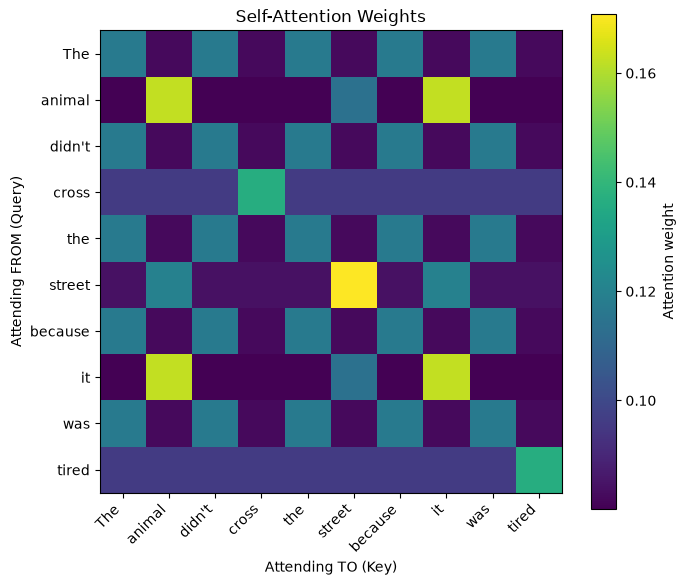

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(attn_weights, cmap="viridis")
ax.set_xticks(range(len(tokens_list)))
ax.set_yticks(range(len(tokens_list)))
ax.set_xticklabels(tokens_list, rotation=45, ha="right")
ax.set_yticklabels(tokens_list)
ax.set_xlabel("Attending TO (Key)")
ax.set_ylabel("Attending FROM (Query)")
ax.set_title("Self-Attention Weights")
fig.colorbar(im, ax=ax, label="Attention weight")
plt.tight_layout()
plt.savefig("attention_heatmap.png", dpi=120)
plt.show()


### Exercise
- Visualize your token_list demo attentions.

**Answer.** The heatmap makes one thing visible that the ranked list hides:
the four function words have *identical* feature vectors, so they form a solid block that cannot
be told apart. That is the gap positional encoding fills.

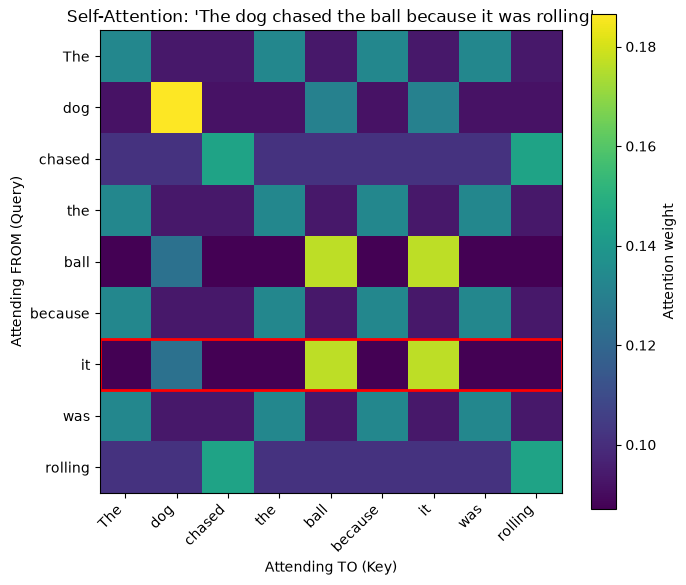

rows for 'The' and 'the' are identical: True


In [7]:
# Exercise - visualise your own sentence's attention matrix.

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(attn_weights_demo, cmap="viridis")
ax.set_xticks(range(len(tokens_list_demo)))
ax.set_yticks(range(len(tokens_list_demo)))
ax.set_xticklabels(tokens_list_demo, rotation=45, ha="right")
ax.set_yticklabels(tokens_list_demo)
ax.set_xlabel("Attending TO (Key)")
ax.set_ylabel("Attending FROM (Query)")
ax.set_title("Self-Attention: 'The dog chased the ball because it was rolling'")

# Mark the row we care about so the coreference link is impossible to miss.
ax.add_patch(plt.Rectangle((-0.5, it_demo - 0.5), len(tokens_list_demo), 1,
                           fill=False, edgecolor="red", lw=2))
fig.colorbar(im, ax=ax, label="Attention weight")
plt.tight_layout()
plt.savefig("attention_heatmap_demo.png", dpi=120)
plt.show()

# The visible structure is block-like: all four function words ("The", "the",
# "because", "was") have identical feature vectors, so they form one bright
# block that attends to itself. Attention cannot tell them apart at all --
# which is exactly the job positional encoding exists to fix.
identical = np.allclose(attn_weights_demo[0], attn_weights_demo[3])
print("rows for 'The' and 'the' are identical:", identical)


## 4. Multi-Head Attention

Instead of one attention computation, run several in parallel — each with its own learned projection — then concatenate and project back down.


In [8]:
def multi_head_attention(X, num_heads, d_model, seed=0):
    rng = np.random.RandomState(seed)
    assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
    d_head = d_model // num_heads

    head_outputs = []
    all_weights = []
    for h in range(num_heads):
        W_q = rng.randn(X.shape[1], d_head) * 0.3
        W_k = rng.randn(X.shape[1], d_head) * 0.3
        W_v = rng.randn(X.shape[1], d_head) * 0.3
        Qh, Kh, Vh = X @ W_q, X @ W_k, X @ W_v
        out_h, w_h = scaled_dot_product_attention(Qh, Kh, Vh)
        head_outputs.append(out_h)
        all_weights.append(w_h)

    concatenated = np.concatenate(head_outputs, axis=-1)   # (seq_len, num_heads * d_head)
    W_o = rng.randn(concatenated.shape[1], d_model) * 0.3   # final linear projection
    output = concatenated @ W_o
    return output, all_weights

mh_output, head_weights = multi_head_attention(X, num_heads=4, d_model=8, seed=1)
print("Multi-head output shape:", mh_output.shape)
print("Number of heads:", len(head_weights))
print("Each head's attention matrix shape:", head_weights[0].shape)

# Do different heads attend differently? Compare where 'it' looks for head 0 vs head 1
for h in range(2):
    order = np.argsort(head_weights[h][it_idx])[::-1][:3]
    print(f"Head {h}: 'it' -> {[tokens_list[i] for i in order]}")


Multi-head output shape: (10, 8)
Number of heads: 4
Each head's attention matrix shape: (10, 10)
Head 0: 'it' -> ['cross', 'tired', 'animal']
Head 1: 'it' -> ['animal', 'it', 'street']


With random projections per head, different heads pick up on different (arbitrary, untrained) aspects of the input — in a trained model, different heads reliably specialize in different relationships (syntax, coreference, topic), exactly as described on Slide 7.


## Exercise
- Change num_heads=4 to num_heads=2
- What happens to d_head?
- Try num_heads=4 and run the cell, observe the output.

**Answer.** `d_head = d_model // num_heads`, so with `d_model=8`:
`num_heads=4` gives `d_head=2`, and `num_heads=2` gives `d_head=4`. The product
`num_heads × d_head` is always `d_model`, which is why the output shape never moves.

In [9]:
# Exercise - change num_heads and watch d_head move.
#
#   d_head = d_model // num_heads
#
# d_model is the width of the model and is FIXED. Splitting it into more heads
# does not add capacity, it re-slices the same capacity into thinner pieces.

print(f"{'num_heads':>10s}{'d_head':>8s}{'concat width':>14s}{'output shape':>15s}")
print("-" * 47)
for nh in (1, 2, 4, 8):
    out_nh, w_nh = multi_head_attention(X, num_heads=nh, d_model=8, seed=1)
    d_head = 8 // nh
    print(f"{nh:>10d}{d_head:>8d}{nh * d_head:>14d}{str(out_nh.shape):>15s}")

print("""
num_heads=4 -> d_head=2      num_heads=2 -> d_head=4

Two things stay constant no matter how you slice it:
  * num_heads x d_head is always d_model (8), because the heads are
    CONCATENATED - that is what keeps the output shape at (10, 8) and lets
    blocks stack.
  * the total amount of attention arithmetic is roughly unchanged.

What changes is the trade-off: more heads = more independent relationships
the layer can look for at once, but each one gets a lower-resolution space to
measure similarity in.""")

# Do fewer, fatter heads actually behave differently? Compare where 'it' looks.
for nh in (2, 4):
    _, w_nh = multi_head_attention(X, num_heads=nh, d_model=8, seed=1)
    print(f"\nnum_heads={nh}:")
    for h in range(nh):
        top = np.argsort(w_nh[h][it_idx])[::-1][:3]
        print(f"  head {h}: 'it' -> {[tokens_list[i] for i in top]}")


 num_heads  d_head  concat width   output shape
-----------------------------------------------
         1       8             8        (10, 8)
         2       4             8        (10, 8)
         4       2             8        (10, 8)
         8       1             8        (10, 8)

num_heads=4 -> d_head=2      num_heads=2 -> d_head=4

Two things stay constant no matter how you slice it:
  * num_heads x d_head is always d_model (8), because the heads are
    CONCATENATED - that is what keeps the output shape at (10, 8) and lets
    blocks stack.
  * the total amount of attention arithmetic is roughly unchanged.

What changes is the trade-off: more heads = more independent relationships
the layer can look for at once, but each one gets a lower-resolution space to
measure similarity in.

num_heads=2:
  head 0: 'it' -> ['cross', 'was', 'The']
  head 1: 'it' -> ['animal', 'it', 'The']

num_heads=4:
  head 0: 'it' -> ['cross', 'tired', 'animal']
  head 1: 'it' -> ['animal', 'it', 'stre

## 5. Positional Encoding

Self-attention alone has no sense of order. Let's implement the original sinusoidal positional encoding and plot it.

$$PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d}}\right), \quad PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$


Positional encoding shape: (50, 64)


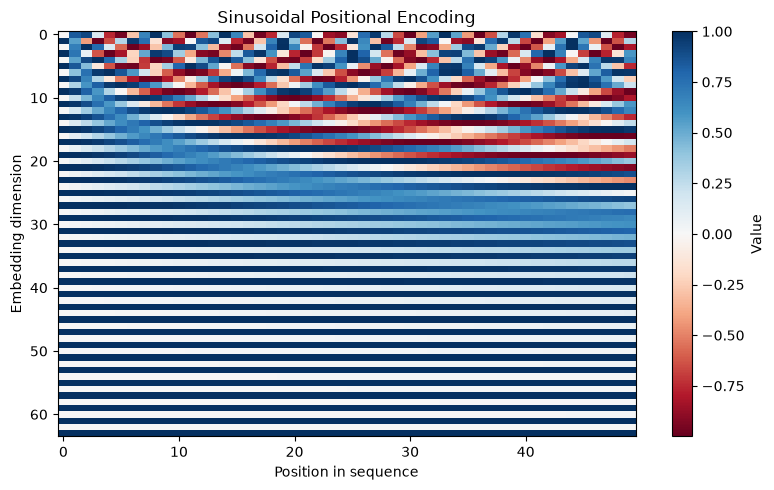

In [10]:
def positional_encoding(seq_len, d_model):
    position = np.arange(seq_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    return pe

pe = positional_encoding(seq_len=50, d_model=64)
print("Positional encoding shape:", pe.shape)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pe.T, cmap="RdBu", aspect="auto")
ax.set_xlabel("Position in sequence")
ax.set_ylabel("Embedding dimension")
ax.set_title("Sinusoidal Positional Encoding")
fig.colorbar(im, ax=ax, label="Value")
plt.tight_layout()
plt.savefig("positional_encoding.png", dpi=120)
plt.show()


Each **column** is a unique pattern across dimensions for that position, and each **row** (dimension) oscillates at a different frequency. No two positions get the same pattern, which is exactly what lets the model distinguish "token 3" from "token 30."


## Exercise
- Change seq_len=50 to seq_len=10
- What is the new shape?


## Exercise
- change d_model=64 to d_model=8
What is the new shape?

**Answer to both shape exercises.** The result is always
`(seq_len, d_model)` — the two arguments are independent, and `d_model` is the one that has to
match your token embeddings.

In [11]:
# Exercise - change seq_len from 50 to 10. What is the new shape?

pe_10 = positional_encoding(seq_len=10, d_model=64)
print("seq_len=10, d_model=64 ->", pe_10.shape)      # (10, 64)

# Exercise - change d_model from 64 to 8. What is the new shape?

pe_d8 = positional_encoding(seq_len=50, d_model=8)
print("seq_len=50, d_model=8  ->", pe_d8.shape)      # (50, 8)
pe_small = positional_encoding(seq_len=10, d_model=8)
print("both changed           ->", pe_small.shape)   # (10, 8)

print("""
The shape is always (seq_len, d_model), and the two arguments are independent:
  seq_len  = how many positions you need a code for   -> number of ROWS
  d_model  = the width of the model's vectors         -> number of COLUMNS

d_model must match the token embeddings, because the two are ADDED elementwise
(x = token_embeddings + pe). seq_len just has to cover the longest sentence.""")

# The rows do not depend on seq_len at all - position 3's code is the same
# whether you asked for 10 positions or 50:
print("row 3 identical in both:", np.allclose(pe_10[3], positional_encoding(50, 64)[3]))

# ...but they DO depend on d_model, because d_model sets the frequencies:
print("row 3 same across widths:", np.allclose(pe_small[3][:8], pe_10[3][:8]))
print("  -> False: the exponent 2i/d_model changes when d_model changes.")


seq_len=10, d_model=64 -> (10, 64)
seq_len=50, d_model=8  -> (50, 8)
both changed           -> (10, 8)

The shape is always (seq_len, d_model), and the two arguments are independent:
  seq_len  = how many positions you need a code for   -> number of ROWS
  d_model  = the width of the model's vectors         -> number of COLUMNS

d_model must match the token embeddings, because the two are ADDED elementwise
(x = token_embeddings + pe). seq_len just has to cover the longest sentence.
row 3 identical in both: True
row 3 same across widths: False
  -> False: the exponent 2i/d_model changes when d_model changes.


## Exercise
- run below and inspect positional encoding.
- Are the encodings for positions 0, 1 and 2 identical? Why?

In [12]:
print(pe[0])
print(pe[1])
print(pe[2])

[0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.]
[8.41470985e-01 5.40302306e-01 6.81561350e-01 7.31760976e-01
 5.33168440e-01 8.46009110e-01 4.09308924e-01 9.12395860e-01
 3.10983593e-01 9.50415280e-01 2.34921076e-01 9.72014449e-01
 1.76892186e-01 9.84230234e-01 1.32957266e-01 9.91121771e-01
 9.98334166e-02 9.95004165e-01 7.49191579e-02 9.97189611e-01
 5.62044992e-02 9.98419278e-01 4.21571532e-02 9.99110992e-01
 3.16175064e-02 9.99500042e-01 2.37115146e-02 9.99718843e-01
 1.77818569e-02 9.99841890e-01 1.33348191e-02 9.99911087e-01
 9.99983333e-03 9.99950000e-01 7.49887181e-03 9.99971883e-01
 5.62338361e-03 9.99984189e-01 4.21695254e-03 9.99991109e-01
 3.16227239e-03 9.99995000e-01 2.37137148e-03 9.99997188e-01
 1.77827847e-03 9.99998419e-01 1.33352104e-03 9.99999111e-01
 9.99999833e-04 9.99999500e-01 7.49894139e-04 9.99999719e-01
 5.62341296

**Answer.** No — and they cannot be. Position 0 is the
distinctive-looking one (`sin(0)=0`, `cos(0)=1`, so it is exactly `[0,1,0,1,...]`), but every
position gets its own fingerprint. Below: why collisions are impossible in practice, plus the
rotation property that makes *relative* position learnable.

pe[0][:8] = [0. 1. 0. 1. 0. 1. 0. 1.]
pe[1][:8] = [0.8415 0.5403 0.6816 0.7318 0.5332 0.846  0.4093 0.9124]
pe[2][:8] = [ 0.9093 -0.4161  0.9975  0.0709  0.9021  0.4315  0.7469  0.6649]

pe[0] == pe[1]? False
pe[1] == pe[2]? False

pe[0] is exactly [0,1,0,1,...]: True

fastest pair omega = 1.0  period = 6.28 positions
slowest pair omega = 0.00013335  period = 47117.2 positions

Two positions could only collide if EVERY one of those sine/cosine pairs
agreed at once. The slowest pair has a period of tens of thousands of
positions, so within any real sequence length no two positions repeat.
That is the whole point: the code has to be a unique fingerprint per slot.
PE(12) reached by rotating PE(7): True
same rotation works from every position p: True


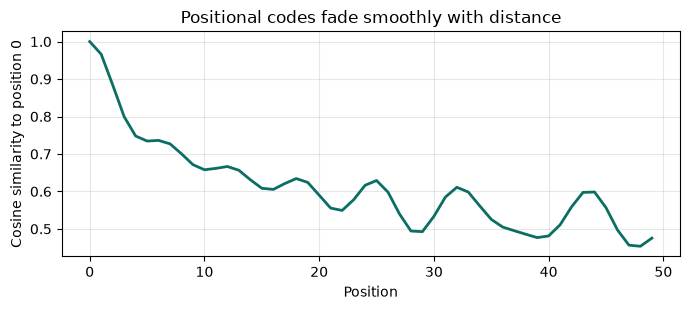


cosine similarity to position 0, first 6 positions: [1.    0.966 0.884 0.8   0.748 0.734]


In [13]:
# Exercise - are the encodings for positions 0, 1 and 2 identical? Why?
#
# Short answer: no, and they cannot be.

print("pe[0][:8] =", np.round(pe[0][:8], 4))
print("pe[1][:8] =", np.round(pe[1][:8], 4))
print("pe[2][:8] =", np.round(pe[2][:8], 4))
print("\npe[0] == pe[1]?", np.allclose(pe[0], pe[1]))
print("pe[1] == pe[2]?", np.allclose(pe[1], pe[2]))

# Position 0 is the one special-looking row: sin(0)=0 and cos(0)=1, so it is
# exactly [0, 1, 0, 1, ...] regardless of d_model.
print("\npe[0] is exactly [0,1,0,1,...]:",
      np.allclose(pe[0][0::2], 0) and np.allclose(pe[0][1::2], 1))

# Every DIMENSION PAIR has its own frequency:  omega_i = 1 / 10000^(2i/d)
d_model = pe.shape[1]
i = np.arange(0, d_model, 2)
omega = 1.0 / (10000 ** (i / d_model))
print("\nfastest pair omega =", round(omega[0], 6),
      " period =", round(2 * np.pi / omega[0], 2), "positions")
print("slowest pair omega =", round(omega[-1], 8),
      " period =", round(2 * np.pi / omega[-1], 1), "positions")
print("""
Two positions could only collide if EVERY one of those sine/cosine pairs
agreed at once. The slowest pair has a period of tens of thousands of
positions, so within any real sequence length no two positions repeat.
That is the whole point: the code has to be a unique fingerprint per slot.""")

# The deeper property: shifting position by k is a fixed ROTATION, the same
# one for every starting position. That is what makes RELATIVE offsets
# learnable by a linear layer.
def rot(theta):
    return np.array([[np.cos(theta), np.sin(theta)],
                     [-np.sin(theta), np.cos(theta)]])

k, pair = 5, 3                      # shift by 5 positions, look at pair 3
w = omega[pair]
v_p = np.array([pe[7, 2 * pair], pe[7, 2 * pair + 1]])       # PE(7)  for that pair
v_q = np.array([pe[7 + k, 2 * pair], pe[7 + k, 2 * pair + 1]])  # PE(12) for that pair
print("PE(12) reached by rotating PE(7):", np.allclose(rot(w * k) @ v_p, v_q))

# ...and the same rotation works from any starting position:
ok = all(np.allclose(rot(w * k) @ np.array([pe[p, 2*pair], pe[p, 2*pair+1]]),
                     np.array([pe[p+k, 2*pair], pe[p+k, 2*pair+1]]))
         for p in range(0, 40))
print("same rotation works from every position p:", ok)

# Similarity between position 0 and every other position decays smoothly -
# nearby positions have similar codes, distant ones do not.
sims = pe @ pe[0] / (np.linalg.norm(pe, axis=1) * np.linalg.norm(pe[0]))
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(sims, color="#0B6E63", lw=2)
ax.set_xlabel("Position")
ax.set_ylabel("Cosine similarity to position 0")
ax.set_title("Positional codes fade smoothly with distance")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pe_similarity.png", dpi=120)
plt.show()
print("\ncosine similarity to position 0, first 6 positions:", np.round(sims[:6], 3))


## 6. A Complete Encoder Block

Let's assemble everything into one full encoder block forward pass: **input + positional encoding → multi-head self-attention → add & norm → feed-forward → add & norm**


In [14]:
def layer_norm(x, eps=1e-6):
    mean = x.mean(axis=-1, keepdims=True)
    std = x.std(axis=-1, keepdims=True)
    return (x - mean) / (std + eps)

def feed_forward(x, d_ff=16, seed=0):
    rng = np.random.RandomState(seed)
    W1 = rng.randn(x.shape[-1], d_ff) * 0.3
    W2 = rng.randn(d_ff, x.shape[-1]) * 0.3
    hidden = np.maximum(0, x @ W1)  # ReLU
    return hidden @ W2

def encoder_block(token_embeddings, num_heads=4, seed=0):
    seq_len, d_model = token_embeddings.shape

    # Step 1: add positional encoding
    pe = positional_encoding(seq_len, d_model)
    x = token_embeddings + pe

    # Step 2: multi-head self-attention, then residual add + layer norm
    attn_out, _ = multi_head_attention(x, num_heads=num_heads, d_model=d_model, seed=seed)
    x = layer_norm(x + attn_out)

    # Step 3: feed-forward network, then residual add + layer norm
    ff_out = feed_forward(x, seed=seed + 1)
    x = layer_norm(x + ff_out)

    return x

encoder_output = encoder_block(X, num_heads=4, seed=2)
print("Input shape:  ", X.shape)
print("Output shape: ", encoder_output.shape)
print("\nOutput is the same shape as the input -- this is what lets encoder blocks stack N times.")


Input shape:   (10, 8)
Output shape:  (10, 8)

Output is the same shape as the input -- this is what lets encoder blocks stack N times.


## Exercise

- Create an array like below pass it to layer_norm and then calculate the mean and standard deviation.

In [15]:
x = np.array([[1, 2, 3, 4],
              [10, 20, 30, 40]], dtype=float)

y = layer_norm(x)
print(y)

print(y.mean(axis=-1))
print(y.std(axis=-1))

[[-1.34163959 -0.4472132   0.4472132   1.34163959]
 [-1.34164067 -0.44721356  0.44721356  1.34164067]]
[0. 0.]
[0.99999911 0.99999991]


**Answer.** Mean 0 and standard deviation 1, per row. The
striking part is that both rows come out **identical** despite differing by a factor of 10 —
layer norm is invariant to any `a·x + b` rescaling, which is exactly what it is for.

In [16]:
# Exercise - layer_norm, then check the mean and standard deviation.

x = np.array([[1, 2, 3, 4],
              [10, 20, 30, 40]], dtype=float)
y = layer_norm(x)
print(y)
print("mean per row:", y.mean(axis=-1))
print("std  per row:", y.std(axis=-1))

# The two rows come out IDENTICAL, even though the inputs differ by 10x:
print("\nrow 0 == row 1 after norm:", np.allclose(y[0], y[1]))
print("""
That is the whole point of layer norm. It subtracts the row's mean and divides
by the row's standard deviation, so any input of the form a*x + b (with a > 0)
lands on exactly the same output. The layer keeps the SHAPE of a token's
feature pattern and throws away its overall scale and offset.""")

a, b = 7.0, -3.0
print("layer_norm(7x - 3) == layer_norm(x):", np.allclose(layer_norm(a * x + b), y))

# The std is 0.99999... rather than exactly 1 because of the eps on the
# denominator, which exists to stop a division by zero on a constant row:
print("\nstd is off by:", 1 - y.std(axis=-1))
flat = np.array([[5.0, 5.0, 5.0, 5.0]])
print("a constant row survives without dividing by zero:", layer_norm(flat))

# Note this implementation normalises with the POPULATION std (ddof=0), and has
# no learnable gain/bias. A real nn.LayerNorm adds  gamma * xhat + beta  so the
# network can undo the normalisation where it needs to.
print("numpy default ddof:", np.std([1., 2., 3., 4.]), "(population, = ddof 0)")


[[-1.34163959 -0.4472132   0.4472132   1.34163959]
 [-1.34164067 -0.44721356  0.44721356  1.34164067]]
mean per row: [0. 0.]
std  per row: [0.99999911 0.99999991]

row 0 == row 1 after norm: True

That is the whole point of layer norm. It subtracts the row's mean and divides
by the row's standard deviation, so any input of the form a*x + b (with a > 0)
lands on exactly the same output. The layer keeps the SHAPE of a token's
feature pattern and throws away its overall scale and offset.
layer_norm(7x - 3) == layer_norm(x): True

std is off by: [8.94426391e-07 8.94427111e-08]
a constant row survives without dividing by zero: [[0. 0. 0. 0.]]
numpy default ddof: 1.118033988749895 (population, = ddof 0)


## 8. Exercises

1. **Scaling matters:** Remove the `/ np.sqrt(d_k)` scaling from `scaled_dot_product_attention` and rerun Section 2 with a much larger `d_model` (e.g., pad the feature vectors to length 256 with zeros). Compare the resulting attention weights — do they become more "peaky" (close to one-hot)? Why does that hurt learning (think about gradients through softmax)?
2. **Masked self-attention:** Implement a `causal_mask(seq_len)` function that returns a matrix of `0`s and `-inf`s such that adding it to the attention scores (before softmax) prevents any position from attending to future positions. Verify that position 0 only attends to itself, position 1 attends to positions 0–1, etc. (This is the decoder's "masked multi-head self-attention" )
3. **More heads, smaller dimension:** Rerun Section 4 with `num_heads=8` instead of `4` (keeping `d_model=8`, so `d_head=1`). What breaks, and why does `d_model % num_heads == 0` matter?
4. **Stack encoder blocks:** Modify `encoder_block` so it can be called twice in a row (`N=2`), feeding the output of the first call as the input to the second. Confirm the shapes still match at every step.


Fill in your answers below.


### Exercise 1 — Scaling matters

**Short answer:** yes, unscaled attention becomes near-one-hot as `d_k` grows, and that kills the
gradient. But the *procedure* the exercise suggests — zero-padding to 256 — does not show it, and
it is worth understanding why. Part A does it as written; Part B does it properly.

In [17]:
# =============================================================================
# Section 8, Exercise 1 - Scaling matters
# =============================================================================
# Claim to test: without the 1/sqrt(d_k) divisor, attention weights get
# "peaky" (nearly one-hot) as d_k grows, and that kills the gradient.

def attention_unscaled(Q, K, V):
    scores = Q @ K.T                       # note: no / sqrt(d_k)
    weights = softmax(scores, axis=-1)
    return weights @ V, weights

# --- Part A: the exercise as literally written (pad the features to 256) -----
X_pad = np.zeros((X.shape[0], 256))
X_pad[:, :X.shape[1]] = X                  # same features, 248 zeros bolted on

_, w_scaled_8 = scaled_dot_product_attention(X, X, X)
_, w_scaled_256 = scaled_dot_product_attention(X_pad, X_pad, X_pad)
_, w_unscaled_256 = attention_unscaled(X_pad, X_pad, X_pad)

print("PART A - zero-padding the hand-made features to d_k=256")
print("  max weight, scaled   d_k=8  :", round(w_scaled_8[it_idx].max(), 4))
print("  max weight, scaled   d_k=256:", round(w_scaled_256[it_idx].max(), 4))
print("  max weight, unscaled d_k=256:", round(w_unscaled_256[it_idx].max(), 4))
print("  unscaled-256 equals scaled-8?",
      np.allclose(w_unscaled_256, softmax(X @ X.T, axis=-1)))
print("""
  Padding with ZEROS does not do what the exercise implies. Q @ K.T is
  completely unchanged by zero columns, so the only thing that moved is the
  divisor: sqrt(256)=16 instead of sqrt(8)=2.83. The scaled version therefore
  gets FLATTER, not peakier, and dropping the scaling just gives back the
  d_k=8 scores exactly.

  The peakiness effect is real, but it needs vectors whose entries actually
  carry signal in every dimension - which is what a trained model has.""")

# --- Part B: the effect the exercise is pointing at --------------------------
# For q, k with independent entries of mean 0 and variance 1:
#     q.k = sum of d_k independent terms  ->  Var(q.k) = d_k,  std = sqrt(d_k)
# So the logits GROW like sqrt(d_k), and softmax saturates.
#
# "mean p(1-p)" below is a proxy for gradient health: the softmax Jacobian
# carries that factor, so when it collapses, so does learning.

def report(scale):
    rng = np.random.RandomState(0)
    print(f"{'d_k':>6s}{'std of scores':>16s}{'max weight':>13s}"
          f"{'entropy':>10s}{'mean p(1-p)':>14s}")
    print("-" * 59)
    for d_k in (8, 64, 256, 1024):
        Qr, Kr = rng.randn(6, d_k), rng.randn(6, d_k)
        s = Qr @ Kr.T
        if scale:
            s = s / np.sqrt(d_k)
        w = softmax(s, axis=-1)
        ent = -(w * np.log(w + 1e-12)).sum(axis=-1).mean()
        print(f"{d_k:>6d}{s.std():>16.2f}{w.max():>13.4f}{ent:>10.3f}"
              f"{(w * (1 - w)).mean():>14.2e}")

print("\nPART B - random vectors, the realistic case")
print("\nWITHOUT the 1/sqrt(d_k) scaling:")
report(scale=False)
print("\nWITH the scaling:")
report(scale=True)

print("""
Unscaled, the score spread grows exactly like sqrt(d_k) (2.6 -> 29 as d_k goes
8 -> 1024), the largest weight saturates at 1.0000, and entropy collapses from
0.80 to 0.02: the softmax has quietly become a hard argmax.

Why that hurts learning. The softmax Jacobian is

    d p_i / d z_j  =  p_i (delta_ij - p_j)

so every gradient term carries a factor of p(1-p). Saturated p means that factor
goes to zero: the mean falls from 6.6e-02 to 1.5e-03, a factor of ~44. Almost no
gradient reaches the queries and keys, and the layer stops learning.

With the scaling, all four columns are essentially flat - std ~1, entropy ~1.5,
gradient scale ~0.12 - regardless of width. That is the entire job of the
divisor: hold the score variance at 1 so the softmax stays in the region where
it still has a derivative, no matter how wide the model gets.""")


PART A - zero-padding the hand-made features to d_k=256
  max weight, scaled   d_k=8  : 0.1625
  max weight, scaled   d_k=256: 0.1097
  max weight, unscaled d_k=256: 0.3016
  unscaled-256 equals scaled-8? True

  Padding with ZEROS does not do what the exercise implies. Q @ K.T is
  completely unchanged by zero columns, so the only thing that moved is the
  divisor: sqrt(256)=16 instead of sqrt(8)=2.83. The scaled version therefore
  gets FLATTER, not peakier, and dropping the scaling just gives back the
  d_k=8 scores exactly.

  The peakiness effect is real, but it needs vectors whose entries actually
  carry signal in every dimension - which is what a trained model has.

PART B - random vectors, the realistic case

WITHOUT the 1/sqrt(d_k) scaling:
   d_k   std of scores   max weight   entropy   mean p(1-p)
-----------------------------------------------------------
     8            2.62       0.8453     0.799      6.64e-02
    64            8.72       0.9836     0.457      4.32e-02

### Exercise 2 — Masked self-attention

**Approach:** add `-inf` to the forbidden scores *before* the softmax, not after. `exp(-inf) = 0`,
so future positions get exactly zero weight and the surviving positions renormalise among
themselves — the row still sums to 1.

causal_mask(5):
[[  0. -inf -inf -inf -inf]
 [  0.   0. -inf -inf -inf]
 [  0.   0.   0. -inf -inf]
 [  0.   0.   0.   0. -inf]
 [  0.   0.   0.   0.   0.]]

masked attention weights (rounded):
[[1.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.33  0.67  0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.37  0.26  0.37  0.    0.    0.    0.    0.    0.    0.   ]
 [0.226 0.226 0.226 0.322 0.    0.    0.    0.    0.    0.   ]
 [0.227 0.159 0.227 0.159 0.227 0.    0.    0.    0.    0.   ]
 [0.134 0.191 0.134 0.134 0.134 0.272 0.    0.    0.    0.   ]
 [0.164 0.115 0.164 0.115 0.164 0.115 0.164 0.    0.    0.   ]
 [0.095 0.194 0.095 0.095 0.095 0.136 0.095 0.194 0.    0.   ]
 [0.128 0.09  0.128 0.09  0.128 0.09  0.128 0.09  0.128 0.   ]
 [0.096 0.096 0.096 0.096 0.096 0.096 0.096 0.096 0.096 0.137]]

position 0 attends only to itself: True
every row has zero weight on the future: True
every row still sums to 1: True
  row 0: 1 non-zero weight(s) -> positions 0..0
  row 1:

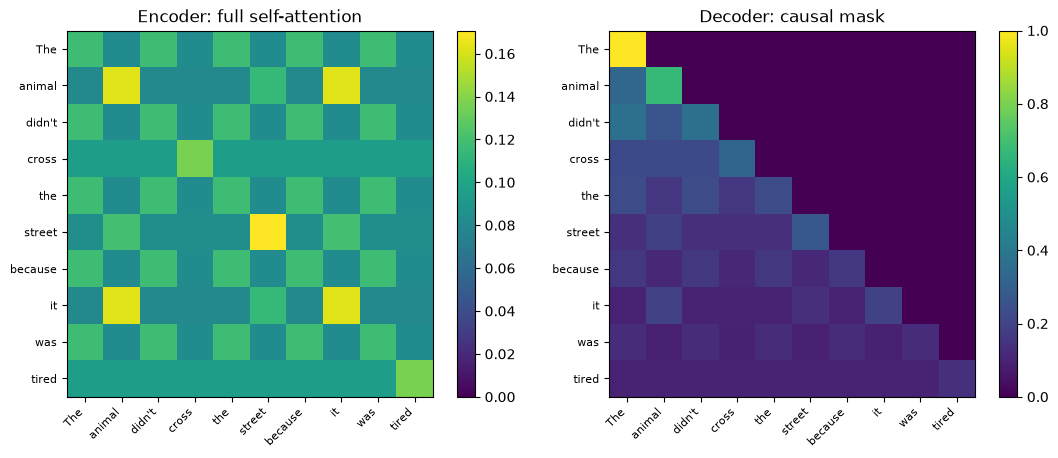

In [18]:
# =============================================================================
# Section 8, Exercise 2 - Masked (causal) self-attention
# =============================================================================
# A decoder generates left to right, so position t must not see t+1, t+2, ...
# The trick: add -inf to the forbidden scores BEFORE the softmax. Since
# exp(-inf) = 0, those positions get exactly zero weight, and the remaining
# weights still sum to 1 on their own.

def causal_mask(seq_len):
    """Upper triangle (strictly above the diagonal) = -inf, everything else 0."""
    return np.triu(np.full((seq_len, seq_len), -np.inf), k=1)

print("causal_mask(5):")
print(causal_mask(5))

def masked_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    scores = scores + causal_mask(Q.shape[0])   # the only added line
    weights = softmax(scores, axis=-1)
    return weights @ V, weights

_, w_causal = masked_attention(X, X, X)
print("\nmasked attention weights (rounded):")
print(np.round(w_causal, 3))

# --- verification --------------------------------------------------------
print("\nposition 0 attends only to itself:", np.allclose(w_causal[0], [1] + [0] * 9))
ok_zero = all(np.allclose(w_causal[i, i + 1:], 0) for i in range(len(X)))
ok_sum = np.allclose(w_causal.sum(axis=1), 1.0)
print("every row has zero weight on the future:", ok_zero)
print("every row still sums to 1:", ok_sum)
for i in (0, 1, 2, 9):
    nz = int((w_causal[i] > 0).sum())
    print(f"  row {i}: {nz} non-zero weight(s) -> positions 0..{i}")

# Why -inf and not just zeroing the weights afterwards: zeroing after the
# softmax would leave the row summing to less than 1, so the token's output
# would silently shrink. Masking BEFORE means the surviving positions
# renormalise among themselves.
scores_plain = X @ X.T / np.sqrt(X.shape[-1])
after = softmax(scores_plain, axis=-1) * (causal_mask(len(X)) == 0)
print("\nnaive 'zero it out afterwards' row sums:", np.round(after.sum(axis=1), 3))
print("-> not 1. Masking before the softmax is what keeps it a distribution.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, w, title in ((axes[0], attn_weights, "Encoder: full self-attention"),
                     (axes[1], w_causal, "Decoder: causal mask")):
    im = ax.imshow(w, cmap="viridis", vmin=0, vmax=w.max())
    ax.set_xticks(range(len(tokens_list))); ax.set_yticks(range(len(tokens_list)))
    ax.set_xticklabels(tokens_list, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(tokens_list, fontsize=8)
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("causal_mask.png", dpi=120)
plt.show()


### Exercise 3 — More heads, smaller dimension

**Short answer:** `num_heads=8` with `d_model=8` does **not** break — `8 % 8 == 0`, so the assert
passes and it runs. What degrades is each head's expressiveness: at `d_head=1` the score matrix is
rank 1. The thing that actually breaks is a `num_heads` that does not divide `d_model`.

In [19]:
# =============================================================================
# Section 8, Exercise 3 - num_heads=8 with d_model=8, so d_head=1
# =============================================================================

out8, w8 = multi_head_attention(X, num_heads=8, d_model=8, seed=1)
print("num_heads=8, d_model=8 -> runs fine. output shape:", out8.shape)
print("d_head =", 8 // 8)

# Nothing raises. The assert passes because 8 % 8 == 0. What degrades is the
# QUALITY of each head: with d_head=1, Qh and Kh are (seq_len, 1) columns, so
#     scores = Qh @ Kh.T
# is an OUTER PRODUCT of two vectors - a rank-1 matrix. A head can only express
# "how strongly does each token emit" x "how strongly does each token receive".
# It cannot represent a genuine pairwise relationship at all.
print("\nrank of one head's score matrix:")
for nh in (8, 4, 2):
    d_head = 8 // nh
    rng = np.random.RandomState(1)
    W_q = rng.randn(X.shape[1], d_head) * 0.3
    W_k = rng.randn(X.shape[1], d_head) * 0.3
    scores = (X @ W_q) @ (X @ W_k).T
    print(f"  num_heads={nh}, d_head={d_head}: rank {np.linalg.matrix_rank(scores)}"
          f"  (upper bound is d_head = {d_head})")

# There is a second, quieter problem: the scaling divisor is sqrt(d_head)=1,
# so a d_head=1 head gets no variance control at all.
print("\nsqrt(d_head) for d_head=1:", np.sqrt(1), "-> the scaling becomes a no-op")

# --- What ACTUALLY breaks: divisibility --------------------------------------
try:
    multi_head_attention(X, num_heads=3, d_model=8, seed=1)
except AssertionError as e:
    print("\nnum_heads=3, d_model=8 ->  AssertionError:", e)

print("""
Why d_model % num_heads == 0 matters: each head produces a (seq_len, d_head)
block, and the heads are CONCATENATED back into (seq_len, num_heads * d_head).
For that to be a drop-in replacement for the input - which is what residual
connections and block stacking require - the concatenated width has to land
back on exactly d_model. If d_model is not divisible by num_heads, integer
division silently loses columns and the shapes stop lining up.

With d_model=8 and num_heads=3, d_head = 8 // 3 = 2, so the heads concatenate
to width 6, not 8. The assert turns that silent shape bug into a loud error.""")


num_heads=8, d_model=8 -> runs fine. output shape: (10, 8)
d_head = 1

rank of one head's score matrix:
  num_heads=8, d_head=1: rank 1  (upper bound is d_head = 1)
  num_heads=4, d_head=2: rank 2  (upper bound is d_head = 2)
  num_heads=2, d_head=4: rank 4  (upper bound is d_head = 4)

sqrt(d_head) for d_head=1: 1.0 -> the scaling becomes a no-op

num_heads=3, d_model=8 ->  AssertionError: d_model must be divisible by num_heads

Why d_model % num_heads == 0 matters: each head produces a (seq_len, d_head)
block, and the heads are CONCATENATED back into (seq_len, num_heads * d_head).
For that to be a drop-in replacement for the input - which is what residual
connections and block stacking require - the concatenated width has to land
back on exactly d_model. If d_model is not divisible by num_heads, integer
division silently loses columns and the shapes stop lining up.

With d_model=8 and num_heads=3, d_head = 8 // 3 = 2, so the heads concatenate
to width 6, not 8. The assert turns that 

### Exercise 4 — Stack encoder blocks

**Short answer:** the shapes match at every step, which is the point of the exercise. But calling
`encoder_block` twice also adds positional encoding twice — a bug that produces no error and no
shape mismatch, just wrong numbers. The fix is to separate "add position once" from "the block".

In [20]:
# =============================================================================
# Section 8, Exercise 4 - Stack encoder blocks (N = 2)
# =============================================================================
# The naive way is to call encoder_block twice. It runs, and the shapes match.
# But look at what encoder_block does on line 1 of its body: it ADDS POSITIONAL
# ENCODING. Calling it twice adds the positional signal twice.

naive_1 = encoder_block(X, num_heads=4, seed=2)
naive_2 = encoder_block(naive_1, num_heads=4, seed=2)
print("naive stacking - shapes are fine:", X.shape, "->", naive_1.shape, "->", naive_2.shape)

# In a real transformer, positional encoding is added ONCE, before block 1.
# Every block after that just transforms whatever it is given. So split the
# block into "add position" and "the block itself":

def encoder_block_core(x, num_heads=4, seed=0):
    """One encoder block WITHOUT re-adding positional encoding."""
    attn_out, _ = multi_head_attention(x, num_heads=num_heads,
                                       d_model=x.shape[-1], seed=seed)
    x = layer_norm(x + attn_out)              # residual + norm
    ff_out = feed_forward(x, seed=seed + 1)
    x = layer_norm(x + ff_out)                # residual + norm
    return x

def encoder_stack(token_embeddings, N=2, num_heads=4, seed=0):
    seq_len, d_model = token_embeddings.shape
    x = token_embeddings + positional_encoding(seq_len, d_model)   # once, up front
    print(f"  after +PE            : {x.shape}")
    for n in range(N):
        x = encoder_block_core(x, num_heads=num_heads, seed=seed + n)
        print(f"  after block {n + 1}        : {x.shape}")
    return x

print("\ncorrect stacking, N=2:")
stacked = encoder_stack(X, N=2, num_heads=4, seed=2)
print("input", X.shape, "-> output", stacked.shape,
      "  shapes match:", stacked.shape == X.shape)

# How different are the two approaches?
diff = np.abs(naive_2 - stacked).max()
print(f"\nmax elementwise difference, naive vs correct: {diff:.4f}")
print("-> the shapes agree, so nothing errors. The VALUES are wrong, silently.")

# Shape preservation is what makes depth possible at all. It holds for any N:
print()
for N in (1, 2, 4, 8):
    x = X + positional_encoding(*X.shape)
    for n in range(N):
        x = encoder_block_core(x, num_heads=4, seed=2 + n)
    print(f"  N={N}: output {x.shape}, all finite: {np.isfinite(x).all()}")

print("""
Why every block has to preserve shape: the residual connection computes
x + sublayer(x), which is only defined if sublayer(x) has exactly x's shape.
That constraint is what forces
    * multi-head attention to project back to d_model, and
    * the feed-forward network to go d_model -> d_ff -> d_model.
Get it right once and the block becomes a LEGO brick you can stack N times.
GPT-3 is this same brick, 96 times, with d_model=12288.""")

# One caveat worth seeing: this toy stack uses a fresh random projection per
# block and has no trained weights, so depth here does not make the output
# "better" - it just shows the plumbing is sound.
print("\nrepresentation drift per layer (mean |cos| between token pairs):")
x = X + positional_encoding(*X.shape)
for n in range(4):
    x = encoder_block_core(x, num_heads=4, seed=2 + n)
    norm = x / np.linalg.norm(x, axis=1, keepdims=True)
    sim = norm @ norm.T
    off = sim[~np.eye(len(x), dtype=bool)]
    print(f"  after block {n + 1}: {np.abs(off).mean():.3f}")
print("""
The tokens get steadily MORE alike with depth (0.58 -> 0.91). That is
'over-smoothing', or attention rank collapse: repeated averaging pulls every
token toward the same vector. Here it happens fast because the projections are
random and untrained. Trained transformers fight it with what is already in
this block - residual connections and layer norm - plus careful initialisation,
which is precisely why those pieces are not optional decoration.""")


naive stacking - shapes are fine: (10, 8) -> (10, 8) -> (10, 8)

correct stacking, N=2:
  after +PE            : (10, 8)
  after block 1        : (10, 8)
  after block 2        : (10, 8)
input (10, 8) -> output (10, 8)   shapes match: True

max elementwise difference, naive vs correct: 1.1913
-> the shapes agree, so nothing errors. The VALUES are wrong, silently.

  N=1: output (10, 8), all finite: True
  N=2: output (10, 8), all finite: True
  N=4: output (10, 8), all finite: True
  N=8: output (10, 8), all finite: True

Why every block has to preserve shape: the residual connection computes
x + sublayer(x), which is only defined if sublayer(x) has exactly x's shape.
That constraint is what forces
    * multi-head attention to project back to d_model, and
    * the feed-forward network to go d_model -> d_ff -> d_model.
Get it right once and the block becomes a LEGO brick you can stack N times.
GPT-3 is this same brick, 96 times, with d_model=12288.

representation drift per layer (mea

---

## 9. What the whole thing adds up to

Every piece in this notebook exists to solve one specific problem, and you can now name each one:

| Piece | The problem it solves |
|---|---|
| **Dot product** `Q @ K.T` | How do I measure which tokens are relevant to each other? |
| **`/ sqrt(d_k)`** | Keeps score variance at 1 so the softmax keeps a usable gradient as the model widens. |
| **Softmax** | Turn scores into weights that sum to 1, so the output is an average and cannot blow up. |
| **Multiple heads** | One similarity function can only measure one kind of relationship at a time. |
| **`W_o` projection** | Concatenated heads must land back on `d_model` for the residual to work. |
| **Positional encoding** | Attention is permutation-invariant — without this, word order does not exist. |
| **Residual `x + sublayer(x)`** | Gives gradients a path around the sublayer, so depth is trainable. |
| **Layer norm** | Holds activations at a stable scale, and resists the rank collapse Exercise 4 shows. |
| **Feed-forward** | Attention only *mixes* existing values; the FFN is where per-token computation happens. |

**The one-sentence version:** attention is a soft, differentiable dictionary lookup — every token
writes a query, every token advertises a key, and the answer is a weighted average of values —
and everything else in the block exists to make stacking that operation ninety-six times deep
actually trainable.

### Where to go next

1. **Add the learned projections.** Replace `Q = K = V = X` with `X @ W_q`, `X @ W_k`, `X @ W_v` and
   see that the mechanism does not change — only where the features come from.
2. **Cross-attention.** Let Q come from one sequence and K, V from another. That single change turns
   the encoder block into a decoder block, and is how translation worked before decoder-only models.
3. **Backpropagate through it.** Everything here is differentiable. Implementing the backward pass
   for `softmax` is the fastest way to make the `p(1-p)` argument from Exercise 1 concrete.